**Lab 4: FIR filters and envelopes**

The goal of this lab is to learn how to implement FIR filters in Python, and how we can use them to improve our synthesis.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

**1. Overview of Filtering**

For this lab, we will define an FIR filter as a discrete-time system that converts an input signal $x[n]$ into an output signal $y[n]$ by means of the weighted summation:

$$
y[n] = \sum_{k=0}^M b_kx[n-k]
$$

The function *np.convolve()* is a generic function with which to implement FIR filters. The following code implements a three-point averaging system:

In [2]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
b = np.array([1.0/3, 1.0/3, 1.0/3])
y = np.convolve(b, x)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

Podem observar com el filtre FIR ha suavitzat el pendent de x[N], modificant y[N] i suavitzant el seu pendent.

1.1 Explain the filtering action of the 5-point averager by comparing the plot of the input $x[n]$ and the output $y[n]$. This filter might be called a “smoothing” filter. Note how the transitions from one level to another have been “smoothed.”

The 5-point averager, is used to smooth or average a signal. It operates by averaging the current sample and four previous samples from the input signal to create a smoother output. This filtering action reduces the impact of high-frequency noise and sharp transitions in the input. We can see this from the example above by noteching how the transitions last longer and have less of an angle of attack. It's an overall smoother graphic than the blue one.

*1.2* Define a function `averaging_filter(x, N)` which implements the N-points averaging filter using the `np.convolve` function.

In [3]:
import numpy as np

def averaging_filter(x, N):
    """
    Applies a N-point averaging filter to the input signal x

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the filter
    """

    # Write your code here
    b = np.ones(N)/N    #Crea un array de longitud N on tots els valors són 1 i ho dividim tot entre N
    y = np.convolve(x, b)
    return y

1.3 Run the example above using the `averaging_filter` instead. Change the number N to different values and explain what happen.

In [4]:
# Write your code here
fs = 1
x = [np.floor(x/10) for x in range(50)]
y = averaging_filter(x, N = 10)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')


In [5]:
fs = 1
x = [np.floor(x/10) for x in range(50)]
y = averaging_filter(x, N = 8)

plot_signals([x, y], fs, name=['input x[n]', 'output y[n]'], mode='lines+markers')

Podem observar com a major N, el filtre FIR modifica més el senyal d'entrada reduïnt el seu pendent i suavitzant la seva forma. Per tant, a major N, y[N] s'assembla menys a x[N].

1.4 How would you classify this filter, as a low-pass o high-pass filter?

És un filtre low-pass, perquè suavitza el senyal mitjançant la mitjana d’un conjunt de mostres, cosa que redueix l’impacte del soroll d’alta freqüència o dels canvis ràpids en el senyal. Aquest comportament fa que deixi passar les components de baixa freqüència i atenua les d’alta freqüència, resultant en un senyal més suau.

---

**2. Envelope detector**

Now we'll implement an envelope detector by concatenating two systems: a full-wave rectifier (absolute value) and the N-point averaging filter.

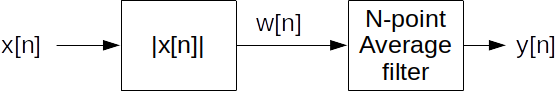

2.1 Define a function `envelope(x, N)` which applies an N-point averaging filter to the full-wave rectified signal and returns the output $y[n]$.

**Note 1**: to calculate the full-wave rectified signal check the `np.abs()` function.

**Note 2**: The output should have the same length as the input signal. Use 'same' mode (see [np.convolve](https://numpy.org/doc/stable/reference/generated/numpy.convolve.html) documentation).

In [6]:
import numpy as np

def envelope(x, N):
    """
    Extracts the envelope of the input signal x by concatenating a full-wave rectifier and an N-point averaging filter.

    Parameters
    ----------
    x : np.array
        The input signal in the form of a numpy array
    N : int
        The number of points used in N-point averaging filter

    Returns
    -------
    y : np.array
        The output of the system, i.e., the envelope of the signal x.
    """
    # write your code here
    b = np.ones(N)/N    #Crea un array de longitud N on tots els valors són 1 i ho dividim tot entre N
    x = np.abs(x)
    y = np.convolve(x, b, mode = "same")
    return y

2.2 Load your reference signal and calculate its envelope using the function you designed. Plot the reference signal and envelope in the same figure.

In [7]:
filepath = "audio/so_guitarra.wav"
ref, fs = load_audio(filepath)

y = envelope(ref, N = 1)

plot_signals([ref, y], fs, name=["Input x[n] (Reference)", "Output y[n] (FIR)"], mode='lines+markers')

2.3 Change the number N to get a good result. What happens when you change the number N?

In [13]:
filepath = "audio/so_guitarra.wav"
ref, fs = load_audio(filepath)

y = envelope(ref, N = 500)

plot_signals([ref, y], fs, name=["Input x[n] (Reference)", "Output y[n] (FIR)"], mode='lines+markers')

Podem observar que tot i canviar els valors d'N, el senyal de sortida del filtre sempre es manté per sobre de l'eix absises (y=0), perquè li hem aplicat un altre filtre, que fa |x[N]|.
A majors valors de N, el filtre agafa més mostres i, per tant, el resultat final està més suavitzat, en canvi, a menor N, l'output és menys suau.

2.4 Explain with your own words why this system achieves extracting the envelope. It might be useful to plot together the signals $x[n]$, $w[n]$ and $y[n]$.

In [14]:
#Absolut w[N]
w = np.abs(ref)

#Output envelope y[N]
N = 500
y = envelope(ref, N)

#Mostrem els 3 senyals
plot_signals([ref, w, y], fs, name=['x[n] (Input)', 'w[n] (Absolut)', 'y[n] (Output)'], mode='lines+markers')

Podem observar la gràfica amb x[N], que és el senyal original, w[N], que és el senyal resultant aplicant el valor absolut, i, finalment, y[N], que és el senyal resultant després d'aplicar envelope.
Aleshores, podem obtenir l'envelope perquè primer rectifiquem el senyal amb el valor absolut i després el suavitzem amb una N gran (N=500). Per tant, el resultat és l'envelope del senyal.

2.5 Now let's apply this envelope to the synthesized signal. Copy the code from Lab3 Ex. 2.1 and generate the synthesized signal. Then multiply the synthesized signal by the envelope. Note that both signal and envelope should have the same length. You can define a time vector of the same length of the envelope to create the signal:

In [ ]:
#CODI LAB 2.1
from IPython.display import Audio
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

f0 = 656.7627
fs = 44100
phi = np.pi
weights = [0.5979, 0.4226, 0.7496, 0.8093, 0.4654, 1, 0.5842, 0.2608]

t = np.linspace(0, len(ref) / fs, len(ref)) #Durada de 0 a 1 segon amb fs mostres per segon

syn = synthesize(f0, phi, weights, t)   #Cridem la funció

samples = int(0.1 * fs)   #Definim quantes mostres hi haurà al gràfic

ref_norm = ref / np.max(np.abs(ref))
syn_norm = syn / np.max(np.abs(syn))

plot_signals([ref_norm[:samples], syn_norm[:samples]], fs, name=['Ref Normalitzat', 'Syn Norm (Lab3)']) #Mostrem els senyals

print("Senyal sintetitzat (Lab3):")
display(Audio(syn, rate = fs))


#MODIFIQUEM
y = envelope(ref, N=500)

syn_Lab4 = y*syn

plot_signals(
    [ref[:samples], syn[:samples], syn_Lab4[:samples]],
    fs,
    name=['Referència', 'Sintetitzat Lab3', 'Sintetitzat Lab4']
)

Senyal sintetitzat (Lab3):


2.6. Compare the spectrograms of the reference signal and the synthesized signal. What are the main differences?

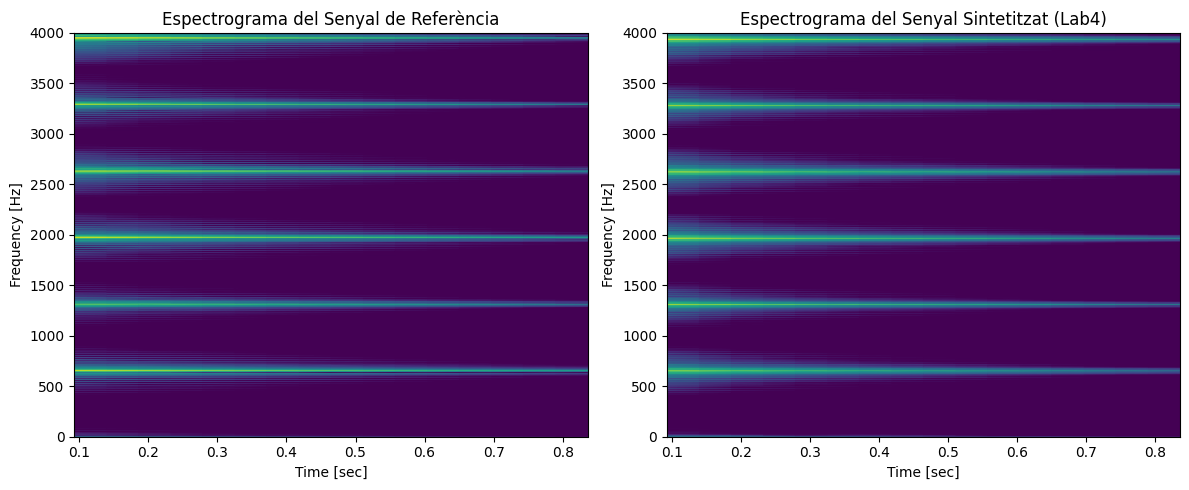

In [11]:
from scipy.signal import spectrogram

window_length = 8192
ff, tt, Sxx = spectrogram(ref, 44100, nperseg=window_length, noverlap=window_length // 2)
ff, tt, Sxx_synLab4 = spectrogram(syn_Lab4, 44100, nperseg=window_length, noverlap=window_length // 2)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_spectrogram(ff, tt, Sxx)
plt.title("Espectrograma del Senyal de Referència")
plt.ylim([0, 4000])

plt.subplot(1, 2, 2)
plot_spectrogram(ff, tt, Sxx_synLab4)
plt.title("Espectrograma del Senyal Sintetitzat (Lab4)")
plt.ylim([0, 4000])

plt.tight_layout()
plt.show()

Podem observar com l’espectrograma del senyal de referència presenta un contingut en freqüències més ric i complex, amb un major nombre d’harmònics i variacions d’intensitat al llarg del temps. En canvi, el senyal sintetitzat mostra menys components espectrals i un patró més net i estable (també, una mica més fort, és a dir, colors més 'forts'), corresponent als harmònics definits en el procés de síntesi. Tot i això, l’evolució temporal és molt similar en tots dos casos, ja que comparteixen la mateixa envolvent, responsable de la forma i la intensitat global del so.

2.7 Listen to the synthesized signal and compare it to the reference.



In [12]:
from IPython.display import Audio
print("Senyal de Referència:")
display(Audio(ref, rate = fs)) #Escoltem el senyal de referència

print("Senyal Sintetitzat (Lab4):")
display(Audio(syn_Lab4, rate = fs)) #Escoltem el senyal sintetitzat

Senyal de Referència:


Senyal Sintetitzat (Lab4):


Podem observar que el senyal sintetitzat és gairebé el mateix que el senyal de referència (original). Això és degut al filtre FIR que hem aplicat, que suavitza i ajusta l'amplitud del senyal sintetitzat per seguir la mateixa forma que el senyal original.